In [1]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1005. Miscellaneous Analyses/P1005.8. Wildfire As Review/Output'
cur_date = '062426'

library(readxl)
library(tidyverse)
library(fastDummies)
library(stringr)
library(reshape2)
library(ggnewscale)
library(patchwork)

# reading in files
info_df = data.frame(read_excel("Input/Extraction Table.xlsx"))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [2]:
colnames(info_df)

[1] "Title"                                  
 [2] "Citation"                               
 [3] "Link.to.Study"                          
 [4] "Location"                               
 [5] "Continent"                              
 [6] "Study.Notes"                            
 [7] "Ref_As_Conc"                            
 [8] "Impacted_Media"                         
 [9] "Primary_Mobilization_Pathway"           
[10] "Other.Potential.Mobilization.Pathway.s."
[11] "Impacted_Water_Resource"                
[12] "Directionality"                         
[13] "Notes.on.Directionality"                
[14] "Magnitude"                              
[15] "Notes.on.Magnitude"                     
[16] "Duration"                               
[17] "Notes.on.Duration"

In [3]:
# only selecting cols of interest
info_df = info_df[,c(1,2,4,8,9,11,12)]
head(info_df)

,Title,Citation,Location,Impacted_Media,Primary_Mobilization_Pathway,Impacted_Water_Resource,Directionality
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,"(Barros et al., 2022)",Australia,Vegetation/soil,Likely runoff,Surface,Increase
2,Impacts-of-Wildfire-in-Clear-Creek-Watershed-on-the-City-of-Goldens-Drinking-Water-Supply.pdf (researchgate.net),"(Boerner et al., 2012)","Colorado, USA",Vegetation/soil,Runoff,Surface,Likely increase
3,Pre- and post-fire pollutant loads in an urban fringe watershed in Southern California,"(Burke et al., 2013)","California, USA",Vegetation/soil,Runoff,Surface,Increase
4,"Trace elements in stormflow, ash, and burned soil following the 2009 Station Fire in southern California","(Burton et al., 2016)","California, USA",Vegetation/soil/built environment,Runoff,Surface,Increase
5,Grazing lambs on pastures regrown after wildfires did not significantly alter metal content in meat and wool (escholarship.org),"(Depenbrock et al., 2022)","California, USA",Vegetation/soil,Likely runoff,Surface,No change
6,Wildfire damage and contamination to private drinking water wells,"(Jankowski et al., 2023)","Colorado, USA",Vegetation/soil/built environment,Likely leaching,Ground,No change


Words about what the heatmap is showing.


In [4]:
heatmap_df = info_df %>%
    unite("location_citation", c("Location", "Citation"), sep = " ") %>%

    # combining some of the categories
     mutate(Primary_Mobilization_Pathway = ifelse(Primary_Mobilization_Pathway == 'Likely runoff', 'Runoff/Likely Runoff', 
                                                ifelse(Primary_Mobilization_Pathway == 'Runoff', 'Runoff/Likely Runoff', 
                                                    ifelse(Primary_Mobilization_Pathway == 'Likely leaching', 'Leaching/Likely Leaching', 
                                                        ifelse(Primary_Mobilization_Pathway == 'Leaching', 'Leaching/Likely Leaching', 
                                                            ifelse(Primary_Mobilization_Pathway == 'Likely deposition', 'Deposition/Likely Deposition',
                                                                   ifelse(Primary_Mobilization_Pathway == 'Deposition', 'Deposition/Likely Deposition',
                                                                       Primary_Mobilization_Pathway)))))),
            Impacted_Water_Resource = ifelse(Impacted_Water_Resource == 'Surface', 'Surface Water Impacts',
                                            ifelse(Impacted_Water_Resource == 'Ground', 'Groundwater Impacts', Impacted_Water_Resource)),
           Impacted_Media = ifelse(Impacted_Media == 'Vegetation/soil/built environment', 'Influenced by Built Environment',
                                            ifelse(grepl('land use', Impacted_Media), 'Influenced by Land Use', Impacted_Media))) %>%

    # creating new cols based on the classes in each of these cols
    dummy_cols(select_columns = c("Impacted_Media", "Primary_Mobilization_Pathway", "Impacted_Water_Resource"),
          remove_first_dummy = FALSE, remove_selected_columns = TRUE) %>%
    # cleaning up col names
    rename_with(~ str_remove(.x, "Primary_Mobilization_Pathway_")) %>%
    rename_with(~ str_remove(.x, "Impacted_Media_")) %>%
    rename_with(~ str_remove(.x, "Impacted_Water_Resource_")) %>%
    select(-`Vegetation/soil`) %>%
    pivot_longer(cols = c(4:10), names_to = "Variable", values_to = "Value") %>%
    mutate(Value = ifelse(Value == 1, 'Yes', 'No')) %>%
    # cleaning up variable names
    mutate(Variable = str_replace_all(Variable, "_", " "),
          Variable = str_replace_all(Variable, "Arsenic", "As"),
          location_citation = str_replace_all(location_citation, ",", ""))

heatmap_df$Value = factor(heatmap_df$Value, levels = c('Yes', 'No'))

head(heatmap_df)

Title,location_citation,Directionality,Variable,Value
<chr>,<chr>,<chr>,<chr>,<fct>
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Influenced by Built Environment,No
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Influenced by Land Use,No
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Deposition/Likely Deposition,No
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Leaching/Likely Leaching,No
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Runoff/Likely Runoff,Yes
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Groundwater Impacts,No


In [5]:
# creating annotation dfs
annotation_df <- unique(heatmap_df[, c("location_citation", "Directionality")])

# creating a df that leaves space b/w the annotation rows and the rest of the heatmap
spacer_df <- annotation_df
spacer_df$Variable <- "Spacer"
spacer_df$Directionality <- NA

annotation_df$Variable <- "Direction"

all_levels <- c("Direction", "Spacer", rev(c('Surface Water Impacts','Groundwater Impacts','Deposition/Likely Deposition', 
                                                             'Leaching/Likely Leaching','Runoff/Likely Runoff',
                                                            'Influenced by Built Environment','Influenced by Land Use')))

heatmap_df$Variable <- factor(heatmap_df$Variable, levels = all_levels)
annotation_df$Variable <- factor(annotation_df$Variable, levels = all_levels)
spacer_df$Variable <- factor(spacer_df$Variable, levels = all_levels)

head(heatmap_df)
head(annotation_df)

Title,location_citation,Directionality,Variable,Value
<chr>,<chr>,<chr>,<fct>,<fct>
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Influenced by Built Environment,No
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Influenced by Land Use,No
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Deposition/Likely Deposition,No
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Leaching/Likely Leaching,No
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Runoff/Likely Runoff,Yes
Wildfires cause rapid changes to estuarine benthic habitat - ScienceDirect,Australia (Barros et al. 2022),Increase,Groundwater Impacts,No


location_citation,Directionality,Variable
<chr>,<chr>,<fct>
Australia (Barros et al. 2022),Increase,Direction
Colorado USA (Boerner et al. 2012),Likely increase,Direction
California USA (Burke et al. 2013),Increase,Direction
California USA (Burton et al. 2016),Increase,Direction
California USA (Depenbrock et al. 2022),No change,Direction
Colorado USA (Jankowski et al. 2023),No change,Direction


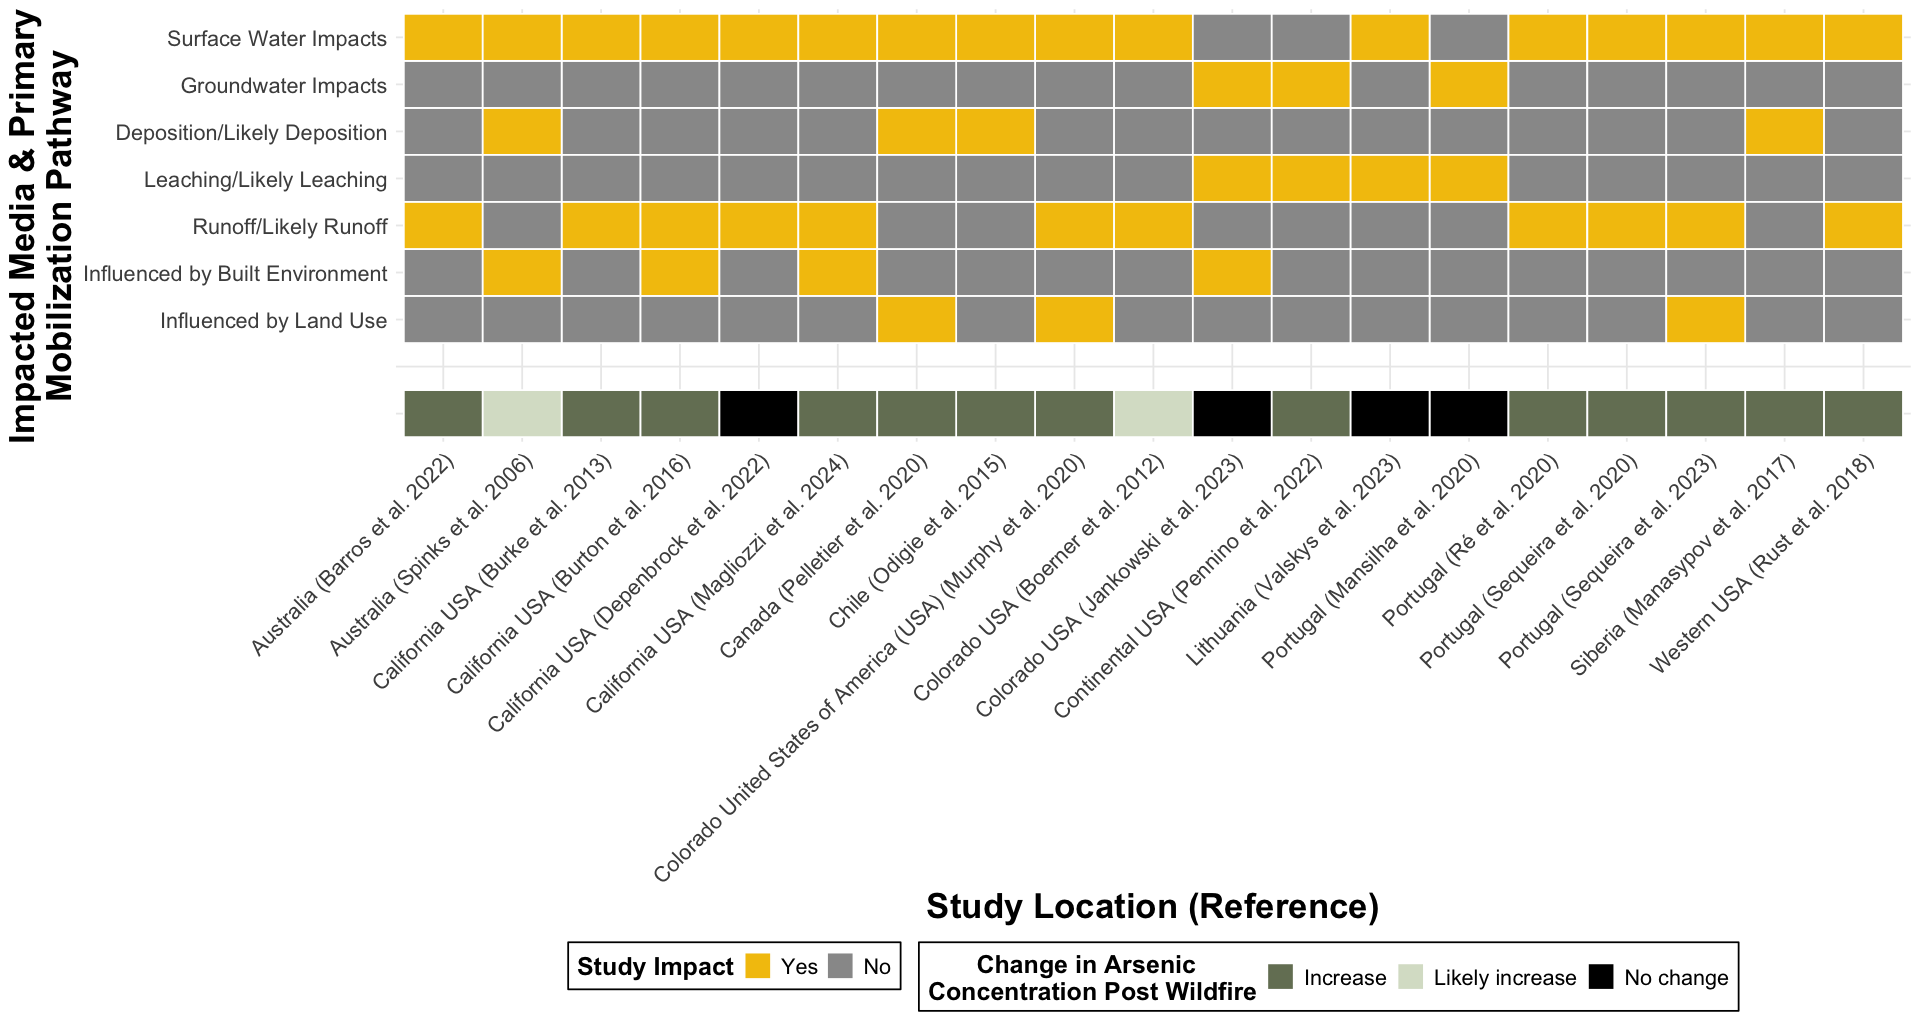

In [6]:
options(repr.plot.width=16, repr.plot.height=8.5) #changing size

Figure3 = ggplot() +

  # Annotation Row Layer
  geom_tile(data = annotation_df, aes(x = location_citation, y = Variable, fill = Directionality),
            color = "white", linewidth = 0.5) + 
   scale_fill_manual(values = c("Increase" = "#757F64", "Likely increase" = "#D9E0CD",
                               "No change" = "black"),
                    name = '       Change in Arsenic\nConcentration Post Wildfire') +
  
  #Clear the fill scale to start a brand new color scale 
  new_scale_fill() +

  #plotting the space
  geom_tile(data = spacer_df, aes(x = location_citation, y = Variable), fill = NA, color = NA) +

  geom_tile(data = heatmap_df, aes(x = location_citation, y = Variable, fill = Value),
            color = "white", linewidth = 0.5) +
    scale_fill_manual(values = c("Yes" = "#f3c30a", "No" = "gray60"),
                   name = "Study Impact") + 

  theme_minimal() +

  theme(axis.title = element_text(face = "bold", size = rel(1.9)),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1),
    axis.text.y = element_text(size = 13), 
    legend.title = element_text(face = "bold", size = 15),
    legend.text = element_text(size = 13), #changes legend text
    legend.position = "bottom",
    legend.background = element_rect(colour = 'black', fill = 'white', linetype = 'solid')) +

  # removing labels from y axis
  scale_y_discrete(labels = function(x) ifelse(x %in% c("Spacer", "Direction"), "", x)) + 

  labs(y = "Impacted Media & Primary\nMobilization Pathway", x = "Study Location (Reference)") 
                   
Figure3

In [7]:
# # exporting figure
# ggsave(Figure3, 
#        filename = 'Figure3.pdf',
#        path = Output,
#        width = 15, height = 7)